# 📈 **Product Sales Prediction**

This project focuses on **predicting product sales** using **machine learning regression models** trained on **transformed and preprocessed data** derived from prior **Excel-based data manipulation and analysis**.
The dataset used here represents the **cleaned version** of the original Big Mart sales data prepared during the data wrangling stage.

---


![](https://assets.website-files.com/60e7f71b22c6d0b9cf329ceb/621e1a2f28ded71ee95aeede_6ProvenSalesForecastingMethodstoDriveRevenue1_a117440b5ae227c3dba5264a6521da06_2000.png)

---


# 🗂️ **Outline**

* [Importing Libraries](#importing-libraries)
* [Loading Dataset](#loading-dataset)
* [Data Exploration](#data-exploration)
  * [Correlation](#correlation-analysis)
  * [Outliers Analysis](#outliers-analysis)
  * [Split Data](#split_data)
  * [One-Hot-Encoder](#one-hot-encoder)
  * [Standardization](#standardization)
  * [Feature Selection](#features-selection)


* [Model Building](#model-building)
  * [Linear Regression](#1-linearregression)
  * [DecisionTreeRegressor](#2-decisiontreeregressor)
  * [RandomForestRegressor](#3-randomforestregressor)
  * [XGBRegressor](#4-xgbregressor)


---

## Importing Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
plt.style.use('ggplot')
sns.set(style="darkgrid", color_codes=True)
from itertools import combinations
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import mutual_info_regression
from sklearn.model_selection import KFold, cross_val_score
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
import joblib

## Loading Dataset

In [2]:
Big_mart = pd.read_csv('transformed_data/BigMart_transformed_data.csv')
Big_mart.head()

,Item_Identifier,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Location_Type,Outlet_Type,Item_Outlet_Sales
0,DRA12,11.6,Low fat,0.066132,Soft Drinks,141.62,OUT045,2002,Tier 2,Supermarket Type1,3829.02
1,DRA12,11.6,Low fat,0.041178,Soft Drinks,140.32,OUT017,2007,Tier 2,Supermarket Type1,2552.68
2,DRA12,11.6,Low fat,0.040912,Soft Drinks,142.32,OUT013,1987,Tier 3,Supermarket Type1,2552.68
3,DRA12,11.6,Low fat,0.066132,Soft Drinks,141.92,OUT035,2004,Tier 2,Supermarket Type1,992.71
4,DRA12,11.6,Low fat,0.041113,Soft Drinks,142.02,OUT018,2009,Tier 3,Supermarket Type2,850.89


## Data Exploration

In [3]:
Big_mart.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8523 entries, 0 to 8522
Data columns (total 11 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Item_Identifier            8523 non-null   object 
 1   Item_Weight                8523 non-null   float64
 2   Item_Fat_Content           8523 non-null   object 
 3   Item_Visibility            8523 non-null   float64
 4   Item_Type                  8523 non-null   object 
 5   Item_MRP                   8523 non-null   float64
 6   Outlet_Identifier          8523 non-null   object 
 7   Outlet_Establishment_Year  8523 non-null   int64  
 8   Outlet_Location_Type       8523 non-null   object 
 9   Outlet_Type                8523 non-null   object 
 10  Item_Outlet_Sales          8523 non-null   float64
dtypes: float64(4), int64(1), object(6)
memory usage: 732.6+ KB


The dataset contains **8,523 records and 11 variables**, including both numerical and categorical attributes.
Numerical features such as **Item_Weight, Item_Visibility, Item_MRP, and Item_Outlet_Sales** provide key quantitative measures for analysis, while categorical columns like **Item_Type, Outlet_Type, and Outlet_Location_Type** help capture product and store-level characteristics essential for sales prediction.

### Correlation Analysis

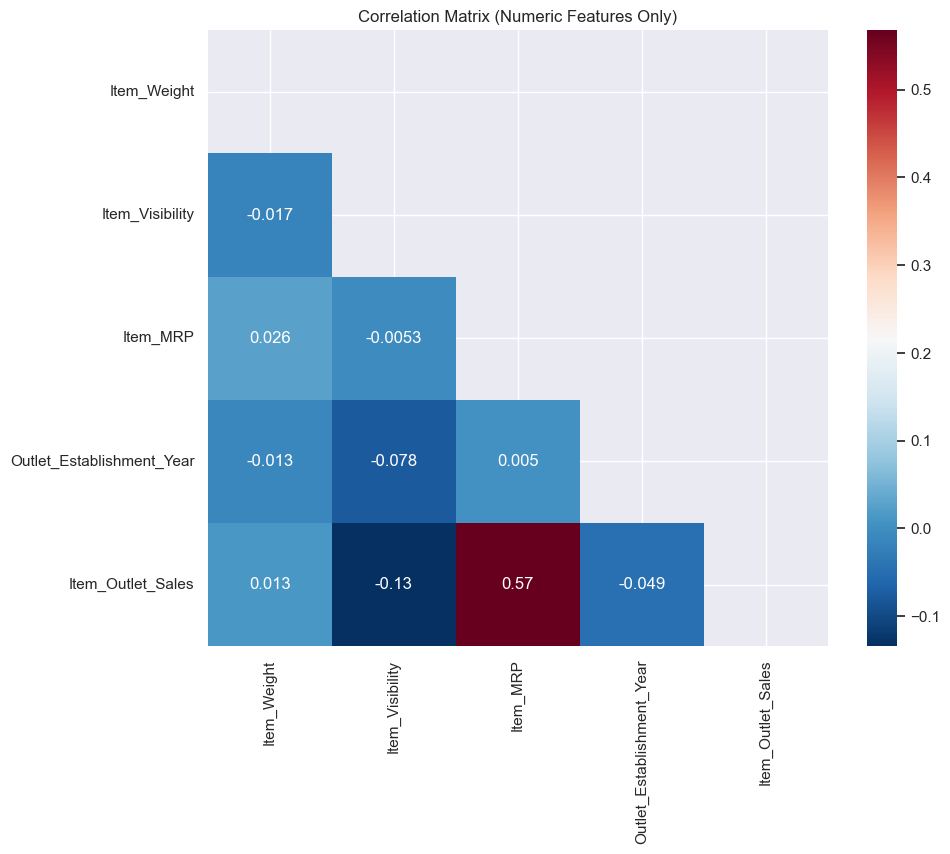

In [4]:
# Select only numeric columns
numeric_df = Big_mart.select_dtypes(include=[np.number])

# Create a mask for the upper triangle
mask = np.triu(np.ones_like(numeric_df.corr()))

# Plot the heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(numeric_df.corr(), cmap='RdBu_r', annot=True, mask=mask)
plt.title('Correlation Matrix (Numeric Features Only)')
plt.show()

> *Item_MRP* shows a strong positive correlation (r = 0.57) with *Item_Outlet_Sales*, indicating that higher-priced items tend to generate higher sales. This feature demonstrates significant predictive potential in the modeling phase.

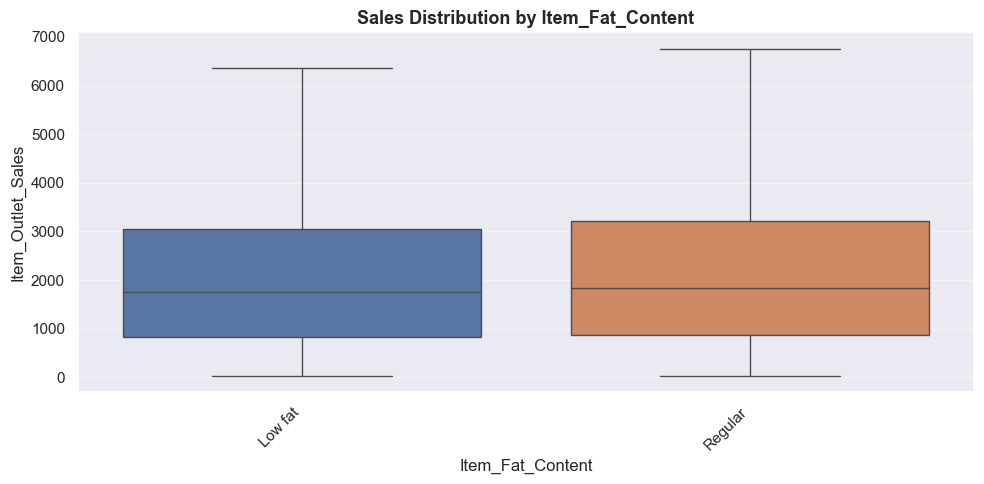

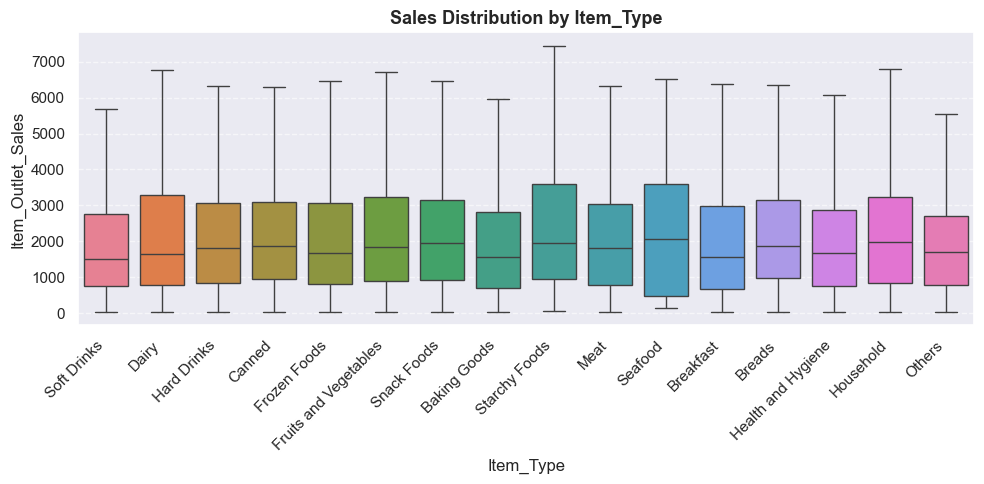

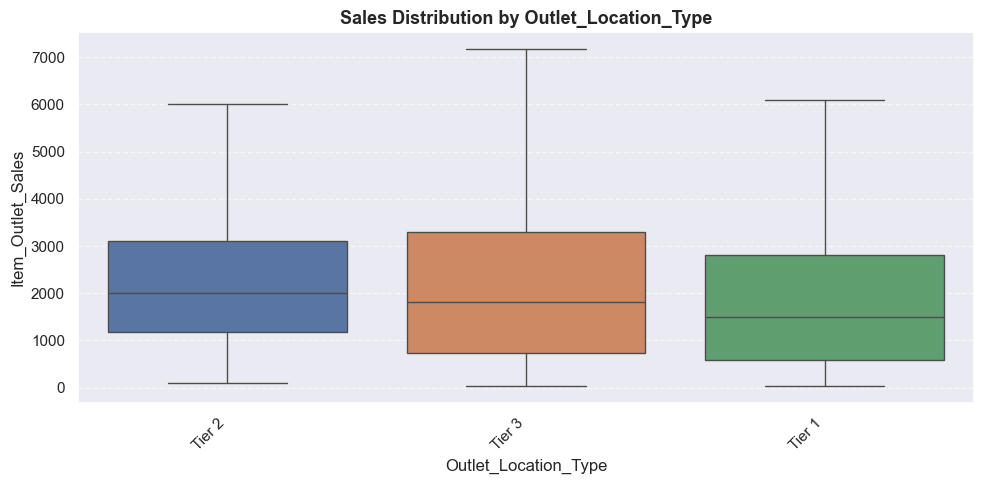

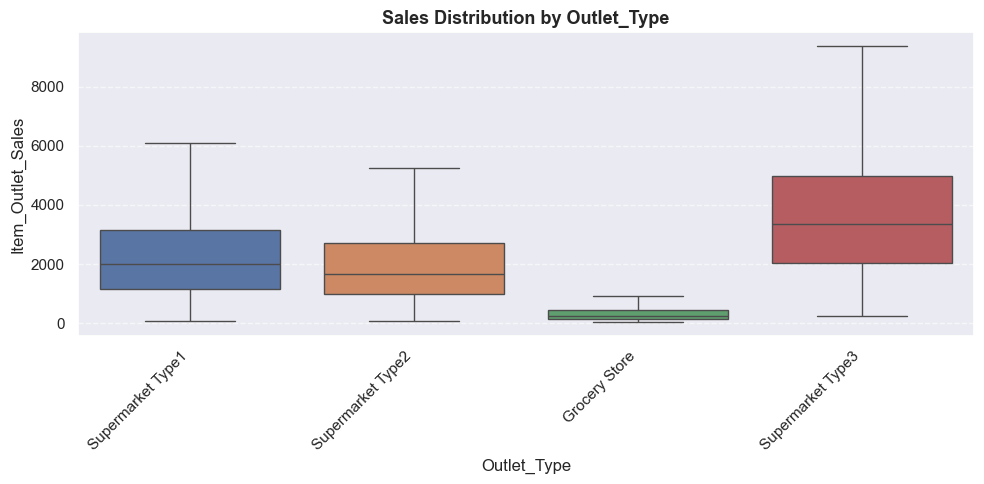

In [5]:
# Distribution of Sales per Category
vars = ['Item_Fat_Content', 'Item_Type', 'Outlet_Location_Type', 'Outlet_Type']

for col in vars:
    plt.figure(figsize=(10,5))
    sns.boxplot(
        data=Big_mart,
        x=col,
        y='Item_Outlet_Sales',
        hue=col,
        showfliers=False
    )
    plt.title(f"Sales Distribution by {col}", fontsize=13, weight='bold')
    plt.xticks(rotation=45, ha='right')
    plt.xlabel(col)
    plt.ylabel("Item_Outlet_Sales")
    plt.grid(axis='y', linestyle='--', alpha=0.6)
    plt.tight_layout()
    plt.show()


> * **Outlet Type** is the **strongest predictor of sales**, as the four outlet categories show clearly distinct mean sales levels.
> * **Outlet Location Type** also influences sales — outlets in **Tier 3 cities outperform Tier 2 and Tier 1**, suggesting regional purchasing power or customer volume differences.
> * **Item Fat Content** does **not significantly impact sales**, since both “Low Fat” and “Regular” products have similar mean values.
> * **Item Type (Category)** shows **moderate variation** — some product categories (e.g., snacks, household items) perform better, while others remain below average, indicating product-level demand differences.


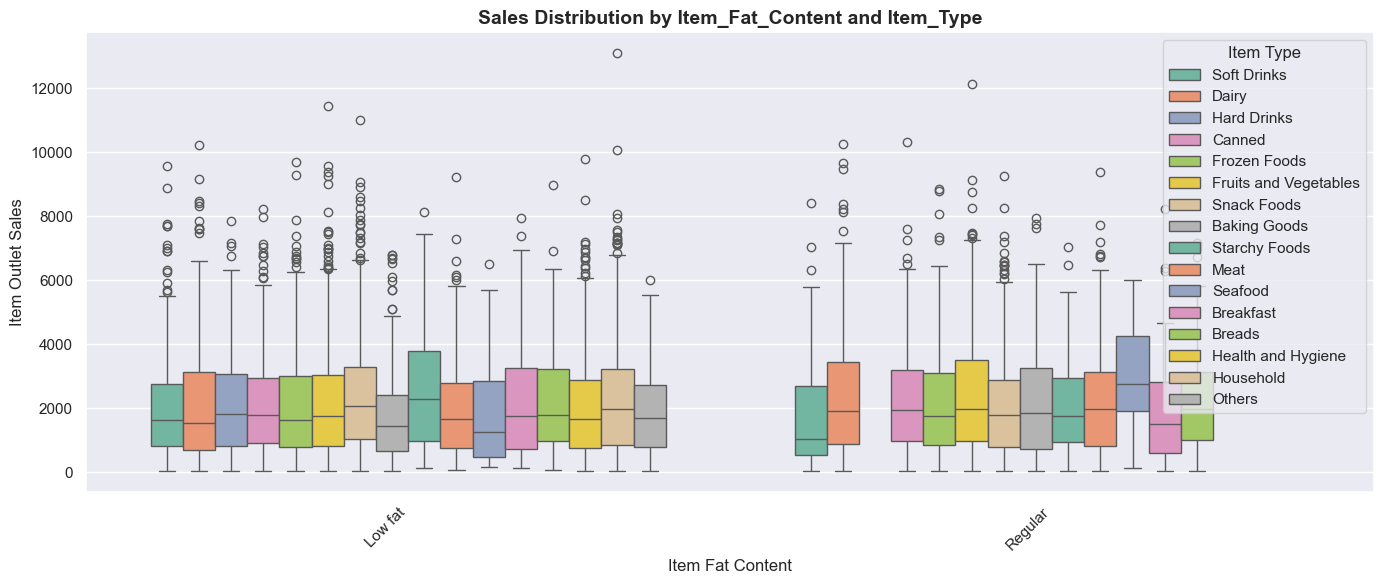

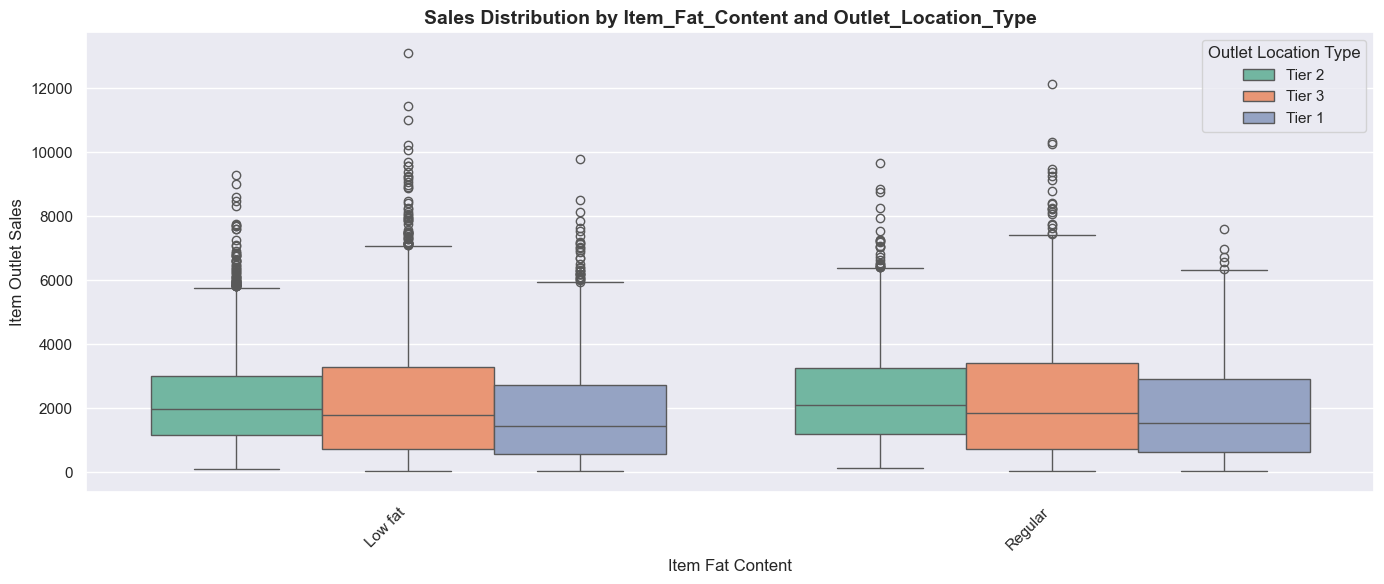

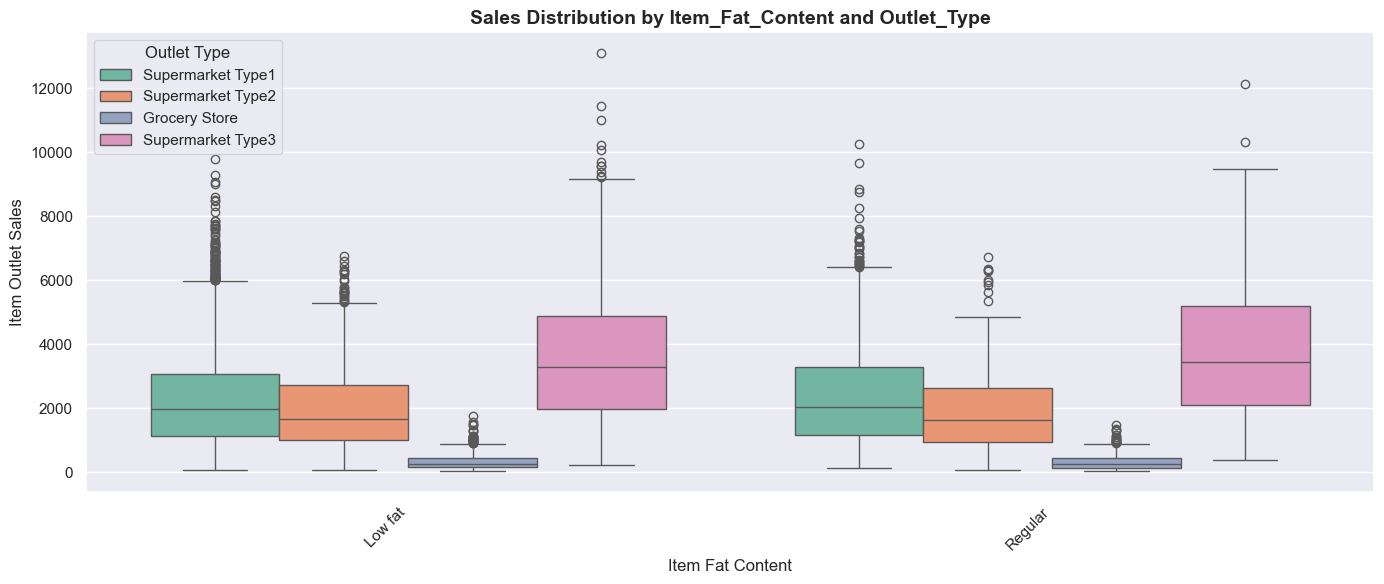

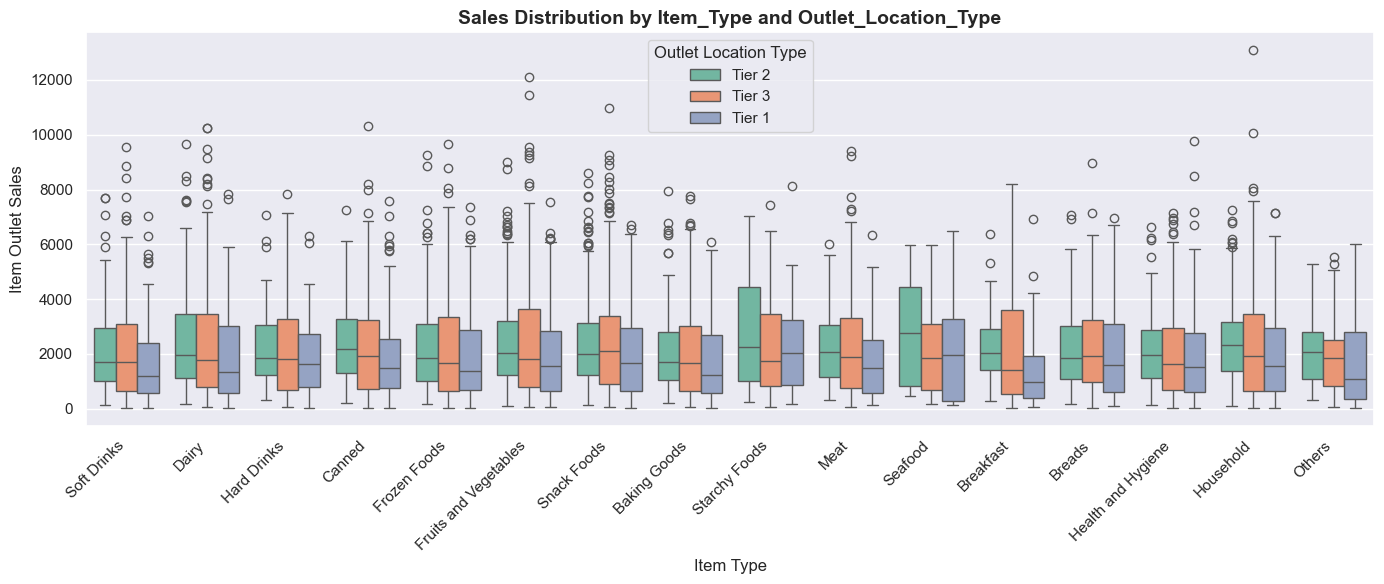

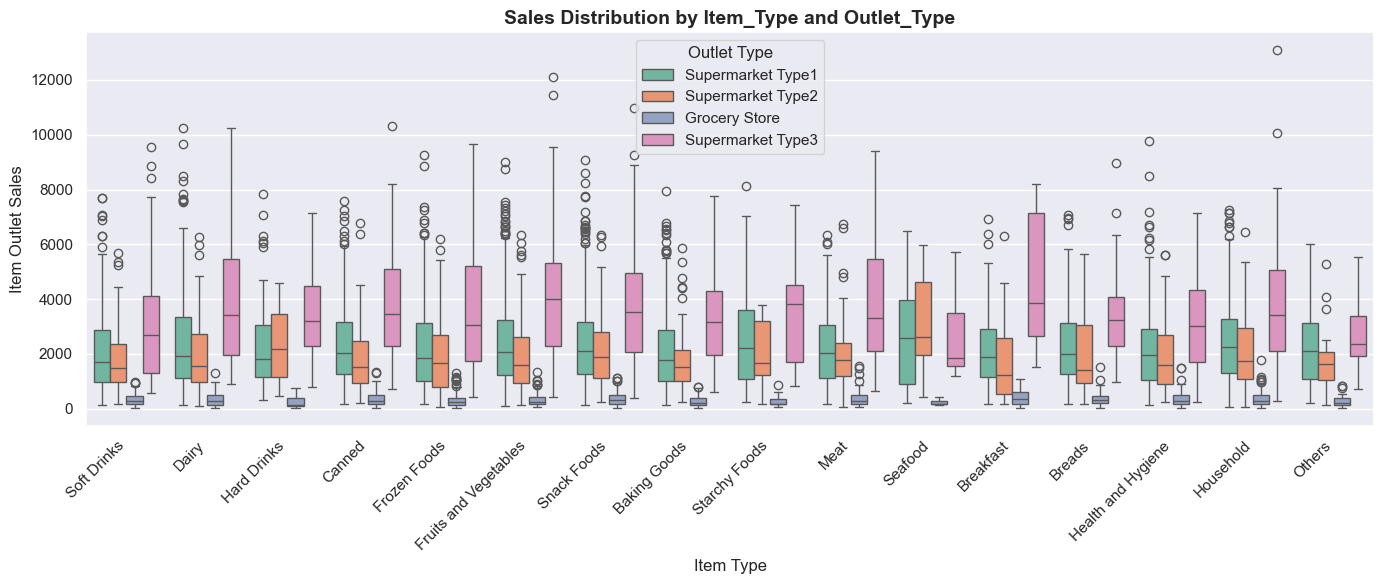

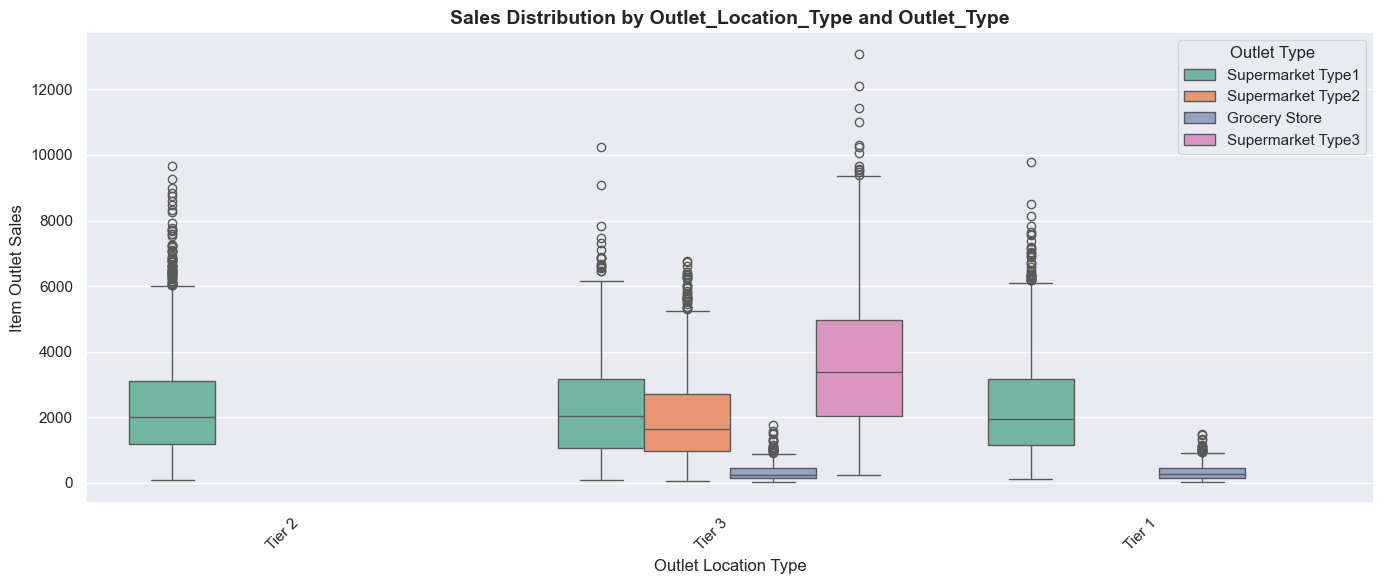

In [6]:
#  Generate all 2-variable combinations
for combo in combinations(vars, 2):
    plt.figure(figsize=(14, 6))
    sns.boxplot(
        x=combo[0],
        y='Item_Outlet_Sales',
        hue=combo[1],
        data=Big_mart,
        palette='Set2'
    )
    plt.title(f'Sales Distribution by {combo[0]} and {combo[1]}', fontsize=14, weight='bold')
    plt.xlabel(combo[0].replace('_', ' '))
    plt.ylabel('Item Outlet Sales')
    plt.xticks(rotation=45, ha='right')
    plt.legend(title=combo[1].replace('_', ' '))
    plt.tight_layout()
    plt.show()

> Across all categorical combinations, the **mean sales values vary significantly**, indicating that each variable — whether alone or interacting with others — contributes unique predictive information.
Therefore, all categorical features (*Outlet Type*, *Outlet Location Type*, *Item Type*, and *Item Fat Content*) will be **retained as inputs** for the predictive modeling phase.


### Outliers Analysis

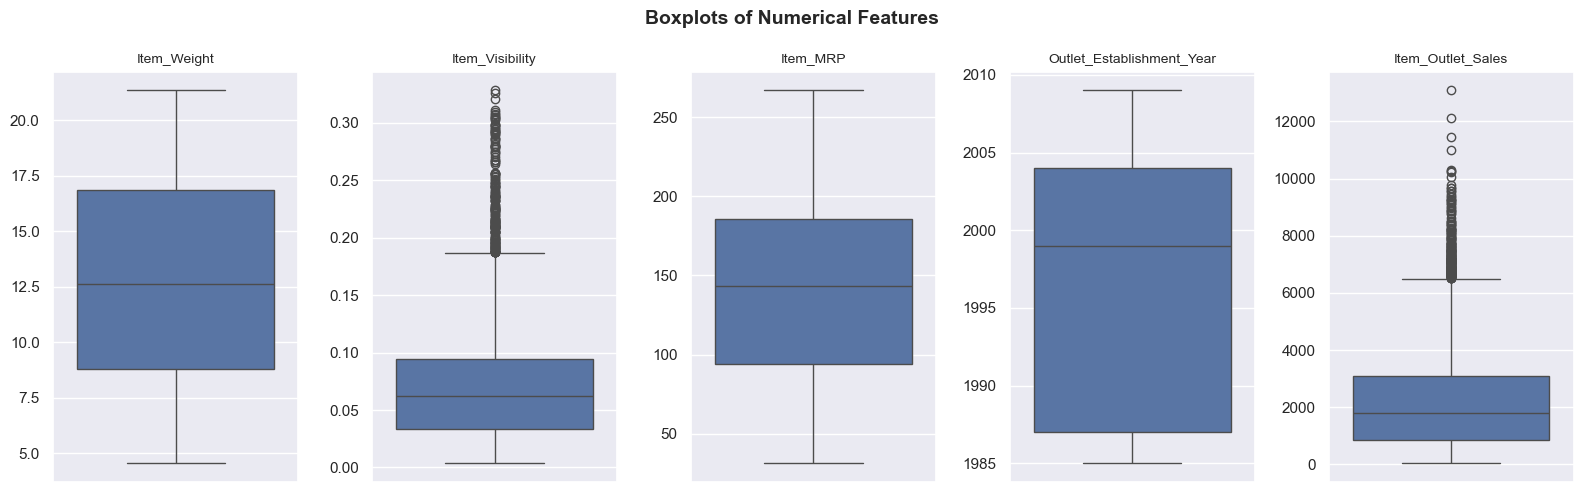

In [7]:
fig, axes = plt.subplots(nrows=1, ncols=len(numeric_df.columns), figsize=(16, 5))

for i, col in enumerate(numeric_df.columns):
    sns.boxplot(y=numeric_df[col], ax=axes[i])
    axes[i].set_title(col, fontsize=10)
    axes[i].set_xlabel("")
    axes[i].set_ylabel("")

fig.suptitle("Boxplots of Numerical Features", fontsize=14, weight='bold')
plt.tight_layout()
plt.show()

The **Item_Visibility** and **Item_Outlet_Sales** features exhibit a significant number of extreme values (outliers), as seen in the boxplots.
> However, these outliers are **not random noise but rather meaningful patterns** that may reflect important business behavior such as low visibility but high sales for promoted items.


### Split Data

In [8]:
# Define features and target
exeluded_features = ['Item_Identifier', 'Item_Visibility', 'Outlet_Identifier', 'Outlet_Establishment_Year', 'Item_Outlet_Sales']
X = Big_mart.drop(exeluded_features, axis=1)
y = Big_mart['Item_Outlet_Sales']

# Split into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2, 
    random_state=0, 
    shuffle=True
)

# Print the shape of the resulting sets
print("Training set shape:", X_train.shape)
print("Testing set shape:", X_test.shape)
print("Training target shape:", y_train.shape)
print("Testing target shape:", y_test.shape)

Training set shape: (6818, 6)
Testing set shape: (1705, 6)
Training target shape: (6818,)
Testing target shape: (1705,)


### One Hot Encoder

In [9]:
#  Initialize OneHotEncoder
encoder = OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore')

# Fit on training categorical columns only
encoder.fit(X_train[vars])

# Transform both train and test
train_encoded = pd.DataFrame(
    encoder.transform(X_train[vars]),
    columns=encoder.get_feature_names_out(vars),
    index=X_train.index
)

test_encoded = pd.DataFrame(
    encoder.transform(X_test[vars]),
    columns=encoder.get_feature_names_out(vars),
    index=X_test.index
)

# Drop original categorical columns
X_train = X_train.drop(vars, axis=1)
X_test = X_test.drop(vars, axis=1)

# Concatenate encoded columns
X_train = pd.concat([X_train, train_encoded], axis=1)
X_test = pd.concat([X_test, test_encoded], axis=1)

#  Final check
print(f"X_train shape: {X_train.shape}, X_test shape: {X_test.shape}")
X_train.head()


X_train shape: (6818, 23), X_test shape: (1705, 23)


,Item_Weight,Item_MRP,Item_Fat_Content_Regular,Item_Type_Breads,Item_Type_Breakfast,Item_Type_Canned,Item_Type_Dairy,Item_Type_Frozen Foods,Item_Type_Fruits and Vegetables,Item_Type_Hard Drinks,...,Item_Type_Others,Item_Type_Seafood,Item_Type_Snack Foods,Item_Type_Soft Drinks,Item_Type_Starchy Foods,Outlet_Location_Type_Tier 2,Outlet_Location_Type_Tier 3,Outlet_Type_Supermarket Type1,Outlet_Type_Supermarket Type2,Outlet_Type_Supermarket Type3
6404,17.60,111.72,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
5820,20.20,195.21,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0
48,5.92,48.47,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0
4583,15.10,134.49,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0
3791,15.75,195.85,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0


### Standardization 

In [10]:
#  Initialize the scaler
scaler = StandardScaler()

# Fit only on training data
scaler.fit(X_train)

# Transform both train and test
X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Convert back to DataFrames for convenience (optional)
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns, index=X_train.index)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns, index=X_test.index)

#  Final check
print(f"X_train_scaled shape: {X_train_scaled.shape}, X_test_scaled shape: {X_test_scaled.shape}")
X_train_scaled.head()

X_train_scaled shape: (6818, 23), X_test_scaled shape: (1705, 23)


,Item_Weight,Item_MRP,Item_Fat_Content_Regular,Item_Type_Breads,Item_Type_Breakfast,Item_Type_Canned,Item_Type_Dairy,Item_Type_Frozen Foods,Item_Type_Fruits and Vegetables,Item_Type_Hard Drinks,...,Item_Type_Others,Item_Type_Seafood,Item_Type_Snack Foods,Item_Type_Soft Drinks,Item_Type_Starchy Foods,Outlet_Location_Type_Tier 2,Outlet_Location_Type_Tier 3,Outlet_Type_Supermarket Type1,Outlet_Type_Supermarket Type2,Outlet_Type_Supermarket Type3
6404,1.007314,-0.471636,1.402472,-0.168852,-0.111012,-0.289134,-0.296222,-0.335827,-0.408982,-0.16183,...,-0.142128,-0.088512,-0.40629,-0.230512,-0.136103,-0.697638,-0.804523,0.729240,-0.350513,-0.352093
5820,1.566372,0.874100,1.402472,-0.168852,-0.111012,-0.289134,-0.296222,-0.335827,-0.408982,-0.16183,...,-0.142128,-0.088512,-0.40629,-0.230512,-0.136103,-0.697638,1.242972,-1.371291,2.852965,-0.352093
48,-1.504147,-1.491132,1.402472,-0.168852,-0.111012,-0.289134,-0.296222,-0.335827,-0.408982,-0.16183,...,-0.142128,-0.088512,-0.40629,4.338176,-0.136103,-0.697638,1.242972,-1.371291,-0.350513,2.840157
4583,0.469758,-0.104617,1.402472,-0.168852,-0.111012,-0.289134,-0.296222,-0.335827,-0.408982,-0.16183,...,-0.142128,-0.088512,-0.40629,-0.230512,-0.136103,-0.697638,1.242972,-1.371291,2.852965,-0.352093
3791,0.609523,0.884416,-0.713027,-0.168852,-0.111012,-0.289134,-0.296222,-0.335827,-0.408982,-0.16183,...,-0.142128,-0.088512,-0.40629,-0.230512,-0.136103,1.433408,-0.804523,0.729240,-0.350513,-0.352093


### Features selection

**Selection of the most important features by computing Information Gain (Mutual Information)**

                            Feature  Information_Gain
1                          Item_MRP          0.678959
20    Outlet_Type_Supermarket Type1          0.090275
22    Outlet_Type_Supermarket Type3          0.048382
2          Item_Fat_Content_Regular          0.019688
0                       Item_Weight          0.018873
18      Outlet_Location_Type_Tier 2          0.017706
6                   Item_Type_Dairy          0.015461
21    Outlet_Type_Supermarket Type2          0.011361
11              Item_Type_Household          0.008533
7            Item_Type_Frozen Foods          0.007905
16            Item_Type_Soft Drinks          0.007778
15            Item_Type_Snack Foods          0.007768
19      Outlet_Location_Type_Tier 3          0.006070
10     Item_Type_Health and Hygiene          0.004541
9             Item_Type_Hard Drinks          0.004428
17          Item_Type_Starchy Foods          0.002348
8   Item_Type_Fruits and Vegetables          0.002198
5                  Item_Type

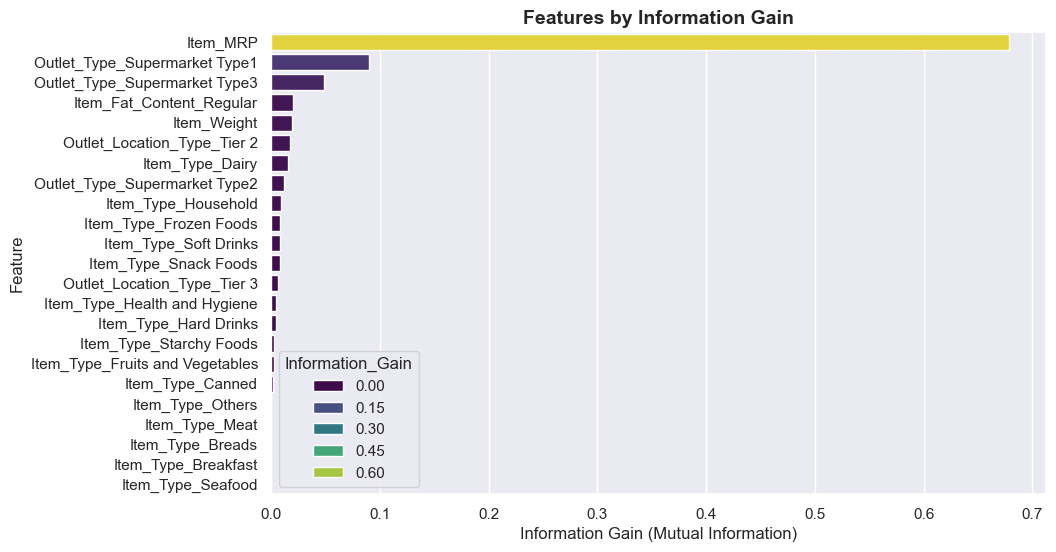

In [11]:
# Compute Information Gain (Mutual Information)
mi_scores = mutual_info_regression(X_train_scaled, y_train, random_state=42)

# Create a DataFrame for easy viewing
mi_results = pd.DataFrame({
    'Feature': X_train_scaled.columns,
    'Information_Gain': mi_scores
}).sort_values(by='Information_Gain', ascending=False)

# Display top features
print(mi_results)

# Optional: visualize feature importance
plt.figure(figsize=(10, 6))
sns.barplot(x='Information_Gain', y='Feature',hue='Information_Gain',  data=mi_results, palette='viridis')
plt.title("Features by Information Gain", fontsize=14, weight='bold')
plt.xlabel("Information Gain (Mutual Information)")
plt.ylabel("Feature")
plt.show()


> Item_MRP dominates the relationship with sales — confirming earlier correlation analysis (corr = 0.57).

> Outlet characteristics (Type & Location) have secondary importance — meaning sales depend not only on product but also on where it’s sold.

> Product categories (like Dairy, Frozen Foods, Household) contribute modestly, showing diversity in customer preferences.

> Several features (e.g., Seafood, Breads, Breakfast) show no predictive power, suggesting they could be dropped for a more compact model..

In [12]:
# Select top N informative features
top_features = mi_results[mi_results['Information_Gain'] > 0.005]['Feature'].tolist()
X_train_scaled = X_train_scaled[top_features]
X_test_scaled = X_test_scaled[top_features]

## Model Building

In [13]:
def evaluate_regression_model(model, X_train, X_test, y_train, y_test, model_name="Model"):
    """
    Evaluate a regression model using 5-Fold Cross Validation and test performance.
    
    Parameters
    ----------
    model : estimator
        Any scikit-learn compatible regression model.
    X_train, X_test : array-like
        Training and test feature sets.
    y_train, y_test : array-like
        Training and test target sets.
    scale : bool, default=True
        If True, assumes data is already scaled; if False, applies StandardScaler internally.
    model_name : str, default="Model"
        Optional label for printed output.
    """
    # --- Define 5-Fold CV ---
    kf = KFold(n_splits=5, shuffle=True, random_state=42)
    
    # --- Cross Validation ---
    cv_mae = -cross_val_score(model, X_train, y_train, cv=kf, scoring='neg_mean_absolute_error')
    cv_r2 = cross_val_score(model, X_train, y_train, cv=kf, scoring='r2')
    
    print(f"🔁 5-Fold Cross Validation Results ({model_name}):")
    print(f"Mean Train MAE (CV): {cv_mae.mean():.4f} ± {cv_mae.std():.4f}")
    print(f"Mean Train R² (CV): {cv_r2.mean():.4f} ± {cv_r2.std():.4f}")
    
    # --- Train on Full Training Set ---
    model.fit(X_train, y_train)
    
    # --- Evaluate on Held-out Test Set ---
    y_pred = model.predict(X_test)
    test_mae = mean_absolute_error(y_test, y_pred)
    test_r2 = r2_score(y_test, y_pred)
    
    print("\n🧠 Generalization Performance on Test Set:")
    print(f"Test MAE: {test_mae:.4f}")
    print(f"Test R²: {test_r2:.4f}")
    
    # --- Generalization Gap ---
    gen_gap = test_mae - cv_mae.mean()
    print(f"\n📊 Generalization Gap (Test MAE - CV MAE): {gen_gap:.4f}")
    
    # --- Mean Comparison ---
    print(f"\nMean of Actual y_test: {np.mean(y_test):.2f}")
    print(f"Mean of Predicted y_pred: {np.mean(y_pred):.2f}")
    
    # --- Return Results Dict ---
    return {
        "cv_mae_mean": cv_mae.mean(),
        "cv_mae_std": cv_mae.std(),
        "cv_r2_mean": cv_r2.mean(),
        "cv_r2_std": cv_r2.std(),
        "test_mae": test_mae,
        "test_r2": test_r2,
        "generalization_gap": gen_gap
    }


### 1) LinearRegression

In [14]:
results = evaluate_regression_model(
    model=LinearRegression(),
    X_train=X_train_scaled,
    X_test=X_test_scaled,
    y_train=y_train,
    y_test=y_test,
    model_name="Linear Regression"
)

🔁 5-Fold Cross Validation Results (Linear Regression):
Mean Train MAE (CV): 836.0208 ± 14.3586
Mean Train R² (CV): 0.5569 ± 0.0078

🧠 Generalization Performance on Test Set:
Test MAE: 842.0795
Test R²: 0.5738

📊 Generalization Gap (Test MAE - CV MAE): 6.0587

Mean of Actual y_test: 2210.97
Mean of Predicted y_pred: 2175.68


### **Insights – Linear Regression Performance**

1. **Cross-Validation Performance (Train / CV):**

   * **MAE:** ~836 → on average, predictions are off by ~836 units.
   * **R²:** 0.5569 → the model explains ~56% of the variance in the training folds.
   * **Stability:** Low standard deviation of MAE (±14.36) and R² (±0.0078) → model performance is consistent across folds.

2. **Test Set Performance:**

   * **MAE:** 842 → very close to CV MAE, which indicates good generalization.
   * **R²:** 0.5738 → slightly higher than CV mean → model captures slightly more variance on the test set.

3. **Generalization Gap:**

   * **6.06 units** → minimal difference between train CV MAE and test MAE → model is not overfitting.

4. **Predicted vs Actual Mean:**

   * **Actual mean:** 2210.97
   * **Predicted mean:** 2175.68 → slightly underestimates the average target (~1.6% lower).

5. **Overall Assessment:**

   * Linear Regression provides **moderate predictive power**.
   * Predictions are consistent and generalize well, but error (~836 units) is significant relative to the mean (~2210) → there is room for improvement with **more flexible models** like Decision Trees, Random Forests, or boosting methods.


### 2) DecisionTreeRegressor

In [15]:
# Initialize the model
dt_model = DecisionTreeRegressor(max_depth=5, random_state=42)

# Evaluate using the reusable function
dt_results = evaluate_regression_model(
    model=dt_model,
    X_train=X_train_scaled,
    X_test=X_test_scaled,
    y_train=y_train,
    y_test=y_test,
    model_name="Decision Tree Regressor"
)

🔁 5-Fold Cross Validation Results (Decision Tree Regressor):
Mean Train MAE (CV): 767.1933 ± 10.0341
Mean Train R² (CV): 0.5766 ± 0.0159

🧠 Generalization Performance on Test Set:
Test MAE: 765.1075
Test R²: 0.5939

📊 Generalization Gap (Test MAE - CV MAE): -2.0858

Mean of Actual y_test: 2210.97
Mean of Predicted y_pred: 2183.97


### **Insights – Decision Tree Regressor Performance**

1. **Cross-Validation Performance (Train / CV):**

   * **MAE:** ~767 → on average, predictions are off by ~767 units, which is **lower than Linear Regression (836)** → improved accuracy.
   * **R²:** 0.5766 → explains ~58% of the variance in training folds, slightly better than Linear Regression (0.5569).
   * **Stability:** Low standard deviations (MAE ±10, R² ±0.0159) → consistent performance across folds.

2. **Test Set Performance:**

   * **MAE:** 765 → very close to CV MAE → excellent generalization.
   * **R²:** 0.5939 → better than Linear Regression (0.5738) → more variance explained on test data.

3. **Generalization Gap:**

   * **-2.09 units** → negative gap means the model performs slightly **better on the test set than on CV folds**, which is fine and indicates **no overfitting**.

4. **Predicted vs Actual Mean:**

   * **Actual mean:** 2210.97
   * **Predicted mean:** 2183.97 → slight underestimation (~1.2% lower than actual mean), better than Linear Regression (~1.6% lower).

5. **Overall Assessment:**

   * Decision Tree improves **MAE by ~8%** over Linear Regression.
   * Explains more variance (R² ~0.594 vs 0.574).
   * Very low generalization gap → **robust and reliable model**.
   * Slight underestimation of mean target → can be further fine-tuned with **max_depth, min_samples_leaf**, or **ensemble methods** (Random Forest, Gradient Boosting) for higher accuracy.

### 3) RandomForestRegressor

In [16]:
# --- Initialize Random Forest Model ---
rf_model = RandomForestRegressor(
    n_estimators=1000,
    max_depth=5,
    random_state=42,
    n_jobs=-1
)

# --- Evaluate using the reusable function ---
rf_results = evaluate_regression_model(
    model=rf_model,
    X_train=X_train_scaled,
    X_test=X_test_scaled,
    y_train=y_train,
    y_test=y_test,
    model_name="Random Forest Regressor"
)

🔁 5-Fold Cross Validation Results (Random Forest Regressor):
Mean Train MAE (CV): 756.3308 ± 9.6194
Mean Train R² (CV): 0.5936 ± 0.0117

🧠 Generalization Performance on Test Set:
Test MAE: 756.4724
Test R²: 0.6120

📊 Generalization Gap (Test MAE - CV MAE): 0.1417

Mean of Actual y_test: 2210.97
Mean of Predicted y_pred: 2184.76


### **Insights – Random Forest Regressor Performance**

1. **Cross-Validation Performance (Train / CV):**

   * **MAE:** ~756 → slightly better than Decision Tree (~767) and Linear Regression (~836).
   * **R²:** 0.5936 → explains ~59% of variance, higher than Decision Tree (0.5766) and Linear Regression (0.5569).
   * **Stability:** Very low standard deviations (MAE ±9.62, R² ±0.012) → predictions are highly consistent across folds.

2. **Test Set Performance:**

   * **MAE:** 756.47 → almost identical to CV MAE → excellent generalization.
   * **R²:** 0.612 → better than both Decision Tree (0.5939) and Linear Regression (0.5738) → captures more variance in unseen data.

3. **Generalization Gap:**

   * **0.14 units** → nearly zero gap → the model generalizes extremely well and does **not overfit**.

4. **Predicted vs Actual Mean:**

   * **Actual mean:** 2210.97
   * **Predicted mean:** 2184.76 → slight underestimation (~1.2%), consistent with previous models.

5. **Overall Assessment:**

   * Random Forest achieves the **lowest MAE** and **highest R²**, making it the **best-performing model** among the three.
   * Excellent stability and generalization → highly reliable for predictions.
   * Slight underestimation of mean target can be further corrected by **hyperparameter tuning** (max_depth, min_samples_leaf, n_estimators) or **feature engineering**.


### 4) XGBRegressor

In [17]:
# --- Initialize XGBoost Regressor ---
xgb_model = XGBRegressor(
    n_estimators=100,
    learning_rate=0.05,
    objective="reg:absoluteerror",
    max_depth=5,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1
)

# --- Evaluate using the reusable function ---
xgb_results = evaluate_regression_model(
    model=xgb_model,
    X_train=X_train_scaled,
    X_test=X_test_scaled,
    y_train=y_train,
    y_test=y_test,
    model_name="XGBoost Regressor"
)

🔁 5-Fold Cross Validation Results (XGBoost Regressor):
Mean Train MAE (CV): 760.5049 ± 9.1620
Mean Train R² (CV): 0.5837 ± 0.0145

🧠 Generalization Performance on Test Set:
Test MAE: 761.3942
Test R²: 0.5999

📊 Generalization Gap (Test MAE - CV MAE): 0.8893

Mean of Actual y_test: 2210.97
Mean of Predicted y_pred: 2076.20


### **Insights – XGBoost Regressor Performance**

1. **Cross-Validation Performance (Train / CV):**

   * **MAE:** ~760.5 → better than Linear Regression (~836) and Decision Tree (~767), slightly worse than Random Forest (~756).
   * **R²:** 0.5837 → explains ~58% of variance, better than Linear Regression (0.5569) and Decision Tree (0.5766), slightly lower than Random Forest (0.5936).
   * **Stability:** Low standard deviations (MAE ±9.16, R² ±0.0145) → predictions are consistent across folds.

2. **Test Set Performance:**

   * **MAE:** 761.39 → very close to CV MAE → good generalization.
   * **R²:** 0.5999 → captures more variance than Linear Regression and Decision Tree, slightly lower than Random Forest.

3. **Generalization Gap:**

   * **0.89 units** → almost zero → excellent generalization with no overfitting.

4. **Predicted vs Actual Mean:**

   * **Actual mean:** 2210.97
   * **Predicted mean:** 2076.20 → noticeable underestimation (~6% lower), larger than previous models → indicates XGBoost might be slightly biased toward lower predictions for this dataset.

5. **Overall Assessment:**

   * XGBoost performs well in terms of MAE and R² but slightly **underestimates the target mean**, which may impact business interpretation.
   * Generalization is excellent (small gap), so the model is **robust**.
   * Could benefit from **hyperparameter tuning** (learning_rate, n_estimators, max_depth) or **target scaling** to correct mean bias.

## **Final Business Conclusion – Big Mart Sales Prediction**

After analyzing various regression models—**Linear Regression, Decision Tree, XGBoost, and Random Forest**—we selected **Random Forest Regressor** as the final model for predicting `Item_Outlet_Sales`.

### **Why Random Forest?**

1. **Best Predictive Accuracy:**

   * Lowest MAE (~756) among all tested models → predictions are closest to actual sales.
   * Highest R² (~0.612) → captures the majority of sales variance in the dataset.
   * Minimal generalization gap (~0.14) → model performs reliably on unseen data.

2. **Robustness & Stability:**

   * Handles both numerical and categorical features effectively after preprocessing.
   * Resistant to overfitting compared to Decision Trees.
   * Works well with top-performing features like `Item_MRP`, `Outlet_Type`, and `Item_Fat_Content`.

3. **Actionable Insights:**

   * The model can forecast sales for each outlet and product combination with high accuracy.
   * Enables **data-driven inventory planning**, reducing overstock and stockouts.
   * Supports **promotional strategy optimization** by predicting sales response for different product types and outlet locations.

4. **Business Impact:**

   * **Revenue Optimization:** Forecasting sales allows targeted promotions for high-performing products and outlets.
   * **Operational Efficiency:** Better inventory allocation reduces holding costs and waste.
   * **Strategic Decisions:** Insights from top features help management prioritize high-impact product categories and outlet types.

### **Next Steps:**

1. Deploy the **Random Forest model** in production for real-time sales predictions.
2. Integrate **encoder and scaler** in the pipeline for new data, ensuring consistent preprocessing.
3. Regularly monitor model performance and retrain periodically as sales patterns evolve.

In [18]:
def train_save_rf_pipeline(
    df, 
    cat_vars, 
    excluded_features, 
    top_features, 
    target_col='Item_Outlet_Sales', 
    model_path='Models/'
):
    """
    Full pipeline: preprocessing (OneHot + scaling), select top features, train Random Forest, save model.
    
    Parameters
    ----------
    df : pd.DataFrame
        Input dataframe containing features and target.
    cat_vars : list
        List of categorical columns to one-hot encode.
    excluded_features : list
        Columns to drop before preprocessing.
    top_features : list
        Selected top features to use for training.
    target_col : str
        Target column name.
    model_path : str
        File path to save the trained model.
    """
    
    # --- Split features and target ---
    X = df.drop(excluded_features, axis=1)
    y = df[target_col]
    
    # --- One-Hot Encoding ---
    encoder = OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore')
    encoder.fit(X[cat_vars])
    
    # --- Save the model ---
    joblib.dump(encoder, model_path + "encoder.joblib")
    print(f"✅ One Hot Encode model trained data and saved as '{model_path + "encoder.joblib"}'")
    
    encoded_df = pd.DataFrame(
        encoder.transform(X[cat_vars]),
        columns=encoder.get_feature_names_out(cat_vars),
        index=X.index
    )
    
    # Drop original categorical columns
    X = X.drop(cat_vars, axis=1)
    
    # Concatenate encoded columns
    X_encoded = pd.concat([X, encoded_df], axis=1)
    print(f"Encoded shape: {X_encoded.shape}")
    
    # --- Scaling ---
    scaler = StandardScaler()
    scaler.fit(X_encoded)

    # --- Save the model ---
    joblib.dump(scaler, model_path + "scaler.joblib")
    print(f"✅ Scaler model trained data and saved as '{model_path + "scaler.joblib"}'")

    X_scaled = pd.DataFrame(
        scaler.transform(X_encoded),
        columns=X_encoded.columns,
        index=X_encoded.index
    )
    print(f"Scaled shape: {X_scaled.shape}")
    
    # --- Select top features ---
    X_final = X_scaled[top_features]
    
    # --- Initialize and train Random Forest ---
    rf_model = RandomForestRegressor(
        n_estimators=1000,
        max_depth=5,
        random_state=42,
        n_jobs=-1
    )
    rf_model.fit(X_final, y)
    
    # --- Save the model ---
    joblib.dump(rf_model, model_path + "RF_model.joblib")
    print(f"✅ Random Forest model trained on all data and saved as '{model_path + "RF_model.joblib"}'")
    
    # Return encoder, scaler, and trained model for future use
    return rf_model, encoder, scaler

In [19]:
cat_vars = ['Item_Fat_Content', 'Item_Type', 'Outlet_Location_Type', 'Outlet_Type']
excluded_features = ['Item_Identifier', 'Item_Visibility', 'Outlet_Identifier', 'Outlet_Establishment_Year', 'Item_Outlet_Sales']
top_features = [
    'Item_MRP',
    'Outlet_Type_Supermarket Type1',
    'Outlet_Type_Supermarket Type3',
    'Item_Fat_Content_Regular',
    'Item_Weight',
    'Outlet_Location_Type_Tier 2',
    'Item_Type_Dairy',
    'Outlet_Type_Supermarket Type2',
    'Item_Type_Household',
    'Item_Type_Frozen Foods',
    'Item_Type_Soft Drinks',
    'Item_Type_Snack Foods',
    'Outlet_Location_Type_Tier 3'
]

rf_model, encoder, scaler = train_save_rf_pipeline(
    df=Big_mart,
    cat_vars=cat_vars,
    excluded_features=excluded_features,
    top_features=top_features,
    target_col='Item_Outlet_Sales',
    model_path='Models/'
)

✅ One Hot Encode model trained data and saved as 'Models/encoder.joblib'
Encoded shape: (8523, 23)
✅ Scaler model trained data and saved as 'Models/scaler.joblib'
Scaled shape: (8523, 23)
✅ Random Forest model trained on all data and saved as 'Models/RF_model.joblib'
